# Toronto Graph Explore

Load the cached Toronto network graph and plot the current nodes and edges. The graph cache comes from `data/processed/THATS/NetworkGraph`:

- `nodes.parquet`: one row per Toronto census tract node
- `edges.parquet`: contiguity edges between neighbouring census tract nodes


In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
project_root = Path("/home/najla/dev/najla-msc")
graph_dir = project_root / "data/processed/THATS/NetworkGraph"

nodes = gpd.read_parquet(graph_dir / "nodes.parquet")
edges = gpd.read_parquet(graph_dir / "edges.parquet")

nodes = nodes.to_crs("EPSG:4326")
edges = edges.to_crs(nodes.crs)

In [4]:
nodes.head()

,loc_name,type,lon,lat,geometry,population,jobs,area,poi_arts_and_entertainment,poi_community_and_government,...,land_use_park,land_use_pedestrian,land_use_protected,land_use_recreation,land_use_religious,land_use_residential,land_use_resource_extraction,land_use_transportation,land_use_winter_sports,original_geometry
loc_id,,,,,,,,,,,,,,,,,,,,,
5320100.01,0100.01,subsector,-78.935020,43.856672,POINT (-78.93502 43.85667),0.000451,0.000203,16220000.0,4.637299e-07,1.391190e-06,...,0.003531,0.000044,0.003211,0.000218,0.000000,0.012452,0.000000,0.001572,0.0,"POLYGON ((670110.57 4858100.098, 670214.479 48..."
5320100.02,0100.02,subsector,-78.966386,43.869987,POINT (-78.96639 43.86999),0.002052,0.000875,2680000.0,3.708509e-07,3.708509e-07,...,0.010381,0.000000,0.000000,0.000587,0.000000,0.134664,0.000000,0.000000,0.0,"POLYGON ((662194.646 4858639.11, 662078.539 48..."
5320100.03,0100.03,subsector,-78.972803,43.882699,POINT (-78.9728 43.8827),0.001365,0.000666,5940000.0,3.367461e-07,3.367461e-07,...,0.014758,0.000000,0.000000,0.000423,0.002103,0.041123,0.000000,0.000000,0.0,"POLYGON ((663940.529 4862096.707, 663973.894 4..."
5320105.14,0105.14,subsector,-78.985482,43.927658,POINT (-78.98548 43.92766),0.000334,0.000157,15920000.0,1.250645e-07,3.126613e-07,...,0.003706,0.000066,0.000000,0.000069,0.000000,0.017175,0.024266,0.000000,0.0,"POLYGON ((663286.006 4866674.193, 663320.67 48..."
5320105.17,0105.17,subsector,-78.992870,43.987493,POINT (-78.99287 43.98749),0.000032,0.000016,52030000.0,3.834821e-08,1.342188e-07,...,0.000096,0.000000,0.000000,0.000019,0.001239,0.000000,0.000000,0.000000,0.0,"POLYGON ((659185.996 4867157.816, 659152.042 4..."


In [6]:
edges.head()

weight  \
5320100.01 5350805.21  5229.881836   
           5320100.02  2923.277907   
           5350805.04  4516.007185   
5320100.02 5350805.21  2780.244458   
           5350805.23  3346.251980   

                                                                geometry  
5320100.01 5350805.21  LINESTRING (-78.93502 43.85667, -78.99952 43.8...  
           5320100.02  LINESTRING (-78.93502 43.85667, -78.96639 43.8...  
           5350805.04  LINESTRING (-78.93502 43.85667, -78.98799 43.8...  
5320100.02 5350805.21  LINESTRING (-78.96639 43.86999, -78.99952 43.8...  
           5350805.23  LINESTRING (-78.96639 43.86999, -79.00756 43.8...

<Axes: >

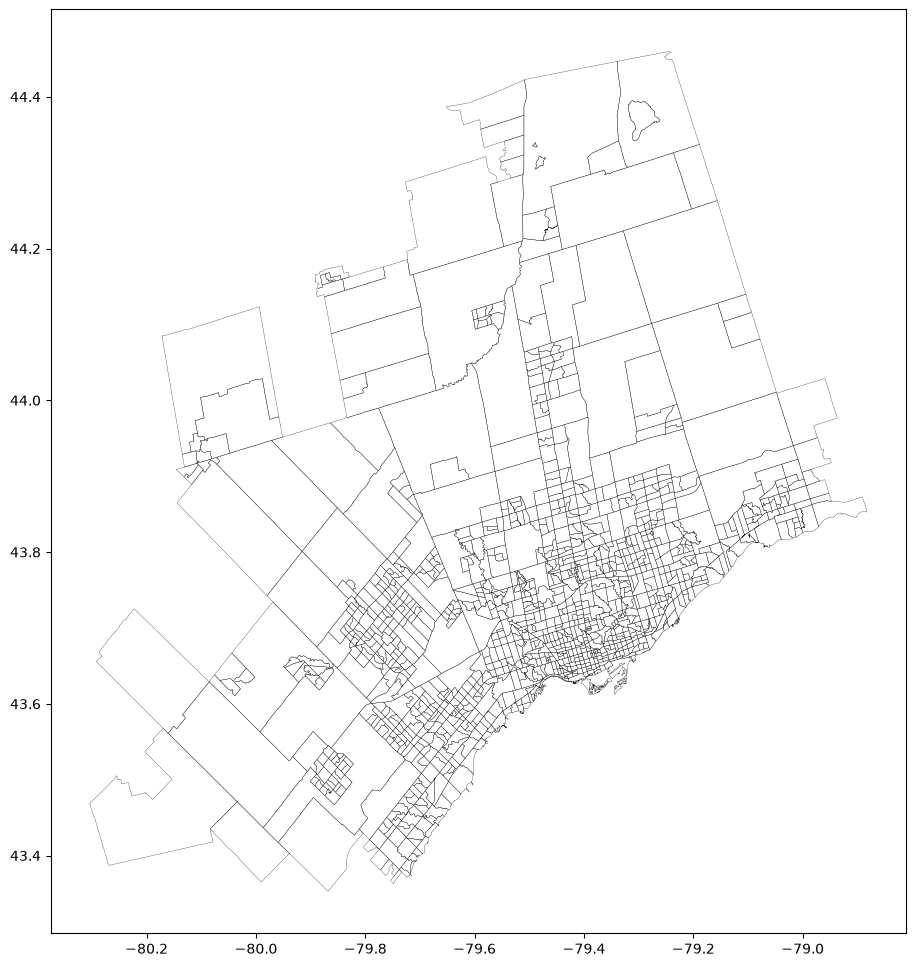

In [ ]:
# show CTs boundary
fig, ax = plt.subplots(figsize=(12, 12))

tracts = nodes.set_geometry("original_geometry").to_crs(nodes.crs)
tracts.boundary.plot(ax=ax, linewidth=0.2, color="#000000")

/tmp/ipykernel_194283/2199062975.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


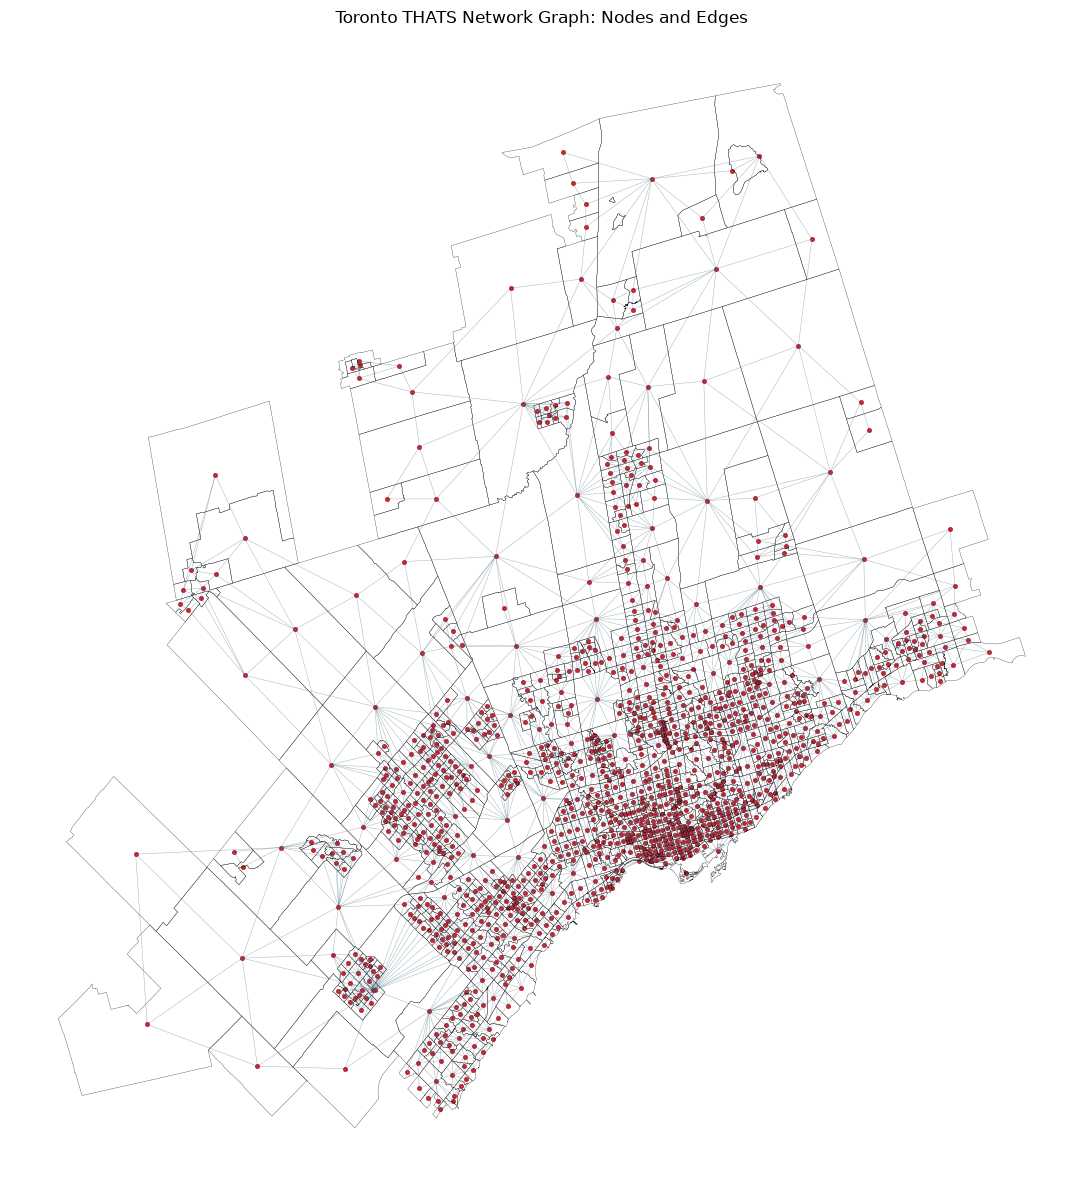

In [14]:
fig, ax = plt.subplots(figsize=(12, 12))
tracts=0
tracts = nodes.set_geometry("original_geometry").to_crs(nodes.crs)
tracts.boundary.plot(ax=ax, linewidth=0.2, color="#000000")

edges.plot(ax=ax, linewidth=0.35, color="#315c72", alpha=0.45)
nodes.plot(ax=ax, markersize=7, color="#c1121f", alpha=0.85)

ax.set_title("Toronto THATS Network Graph: Nodes and Edges")
ax.set_axis_off()
fig.tight_layout()

fig.show()

In [ ]:
#test is there multiple edges per nodes pair?
import pandas as pd

edge_pairs = edges.index.to_frame(index=False)
edge_pairs.columns = ["source", "target"]

# Treat A-B and B-A as the same pair
edge_pairs[["node_a", "node_b"]] = pd.DataFrame(
    sorted([a, b]) for a, b in edge_pairs[["source", "target"]].to_numpy()
)

edge_counts = (
    edge_pairs
    .groupby(["node_a", "node_b"])
    .size()
    .reset_index(name="n_edges")
    .sort_values("n_edges", ascending=False)
)

edge_counts.head()

,node_a,node_b,n_edges
0,5320100.01,5320100.02,1
1,5320100.01,5350805.04,1
2,5320100.01,5350805.21,1
3,5320100.02,5320100.03,1
4,5320100.02,5350805.04,1


In [16]:
edge_counts.query("n_edges > 1")

,node_a,node_b,n_edges


In [23]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

dir = Path("/home/najla/dev/najla-msc/bikeshare/data/processed/bike_ridership")
df_txt_node2vec = pd.read_parquet(dir / "df_txt_node2vec.parquet")

# Total bike trips per graph node across all dates
trip_counts = (
    df_txt_node2vec
    .groupby("loc_id_key", as_index=False)["trip_count"]
    .mean()
    .rename(columns={"trip_count": "avg_trip_count"})
)

# Join trip counts onto graph nodes
nodes_plot = nodes.copy()
nodes_plot["loc_id_key"] = nodes_plot.index.astype(str)

nodes_plot = nodes_plot.merge(
    trip_counts,
    on="loc_id_key",
    how="left",
)

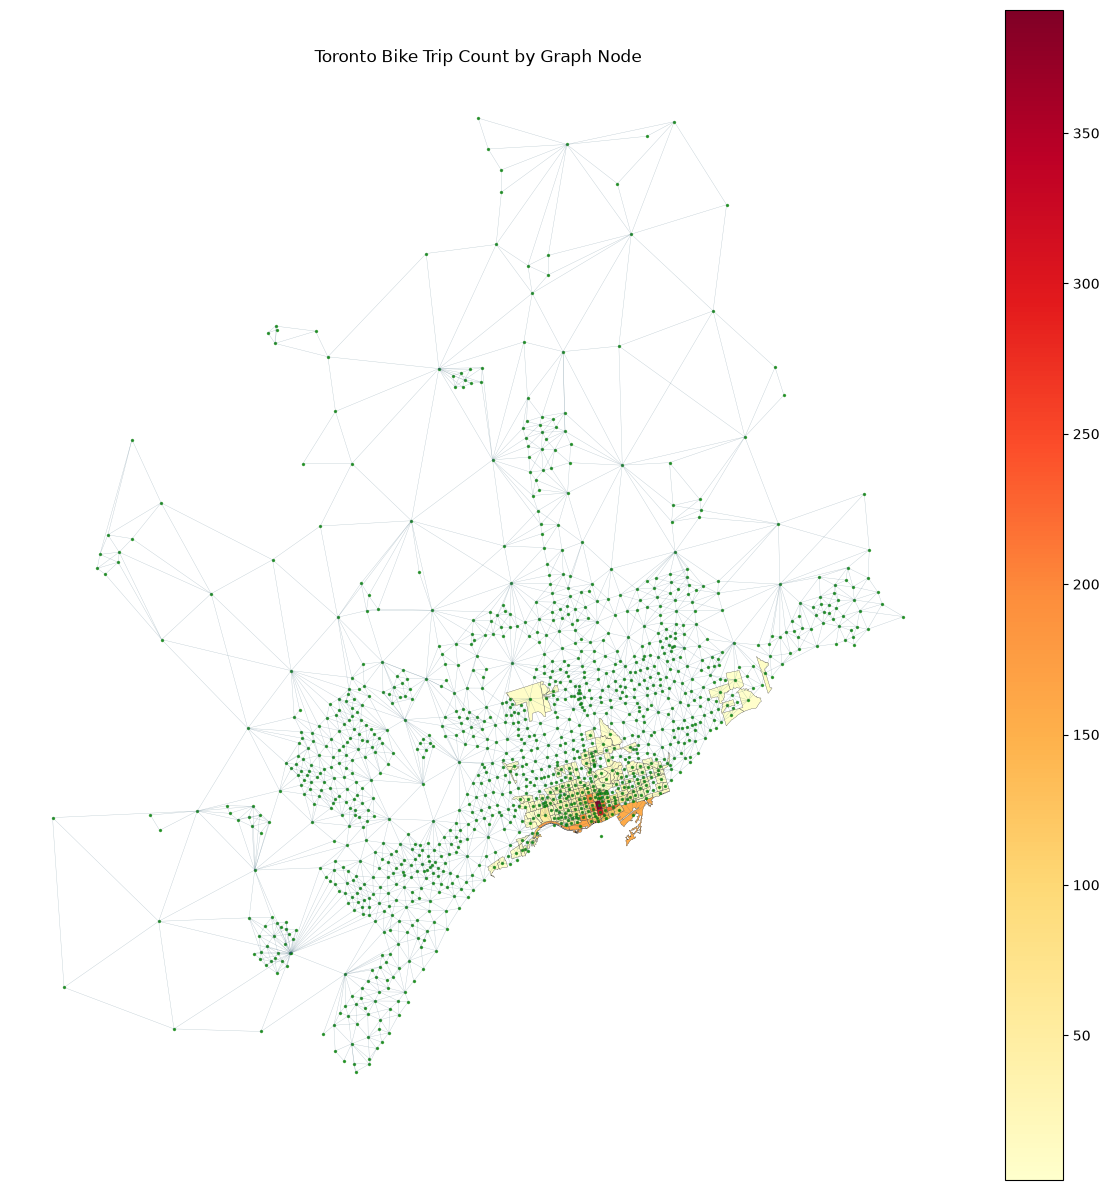

In [27]:
# the CTs are not fully connected, this the 184 stations that I've trips count + location info
fig, ax = plt.subplots(figsize=(12, 12))

# Use original census tract polygons as node backgrounds
node_backgrounds = nodes_plot.set_geometry("original_geometry").to_crs(nodes.crs)

node_backgrounds.plot(
    ax=ax,
    column="avg_trip_count",
    cmap="YlOrRd",
    legend=True,
    linewidth=0.2,
    edgecolor="#333333",
)

edges.plot(ax=ax, linewidth=0.25, color="#315c72", alpha=0.35)
nodes.plot(ax=ax, markersize=2, color="green", alpha=0.7)

ax.set_title("Toronto Bike Trip Count by Graph Node")
ax.set_axis_off()
fig.tight_layout()

plt.show()

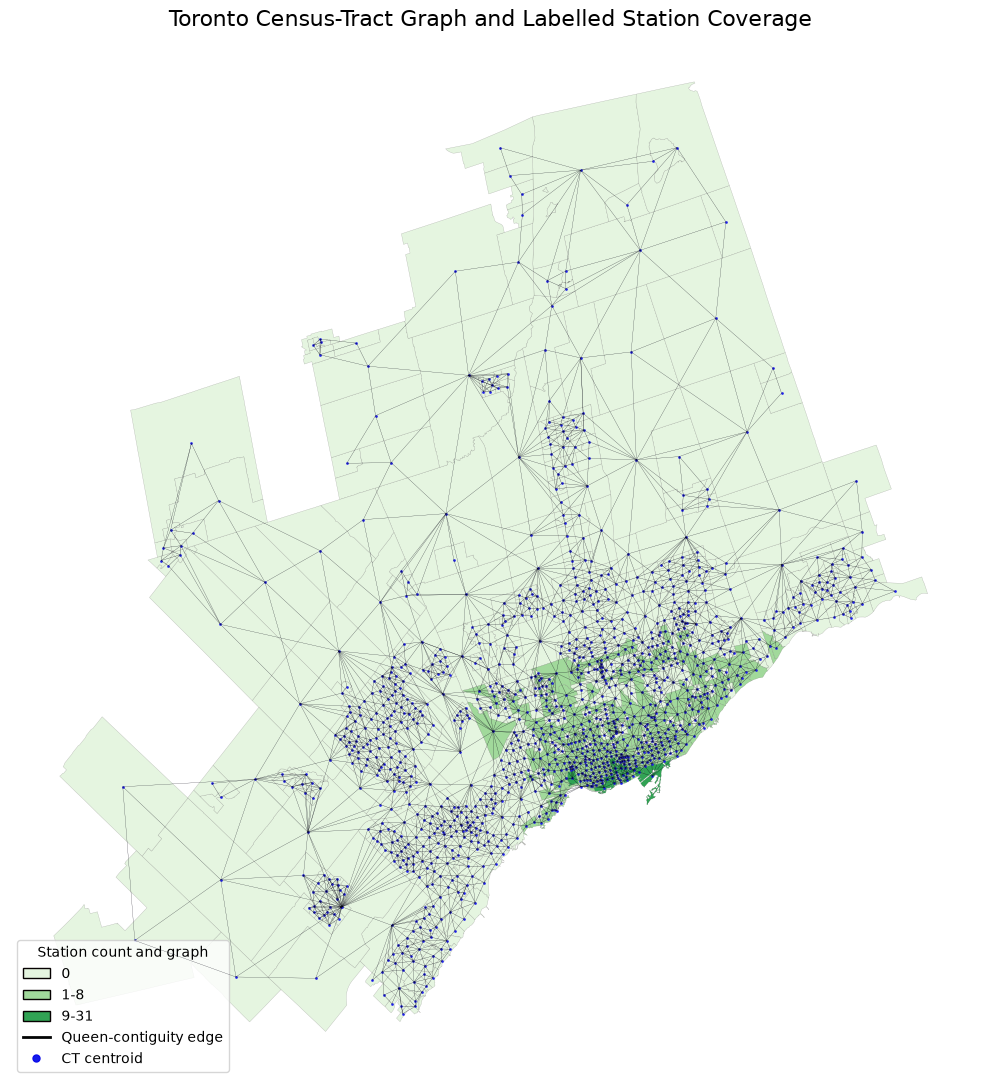

Graph nodes: 1,247
Graph edges: 4,090
Labelled CTs: 363
Unique stations: 1,002
Maximum stations in one CT: 31


In [15]:
# Plot census-tract station coverage and the Queen-contiguity graph.
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import LineString

ROOT = Path("/home/najla/dev/najla-msc/bikeshare")
GRAPH_DIR = ROOT / "data/processed/graph"
MODEL_PATH = ROOT / "data/processed/model_df/desc_semantics/desc_df_2targets_txtTokens_graphFeat.parquet"
ISLAND_LOC_ID = "5350002.00"
PLOT_CRS = "EPSG:26917"

def normalise_loc_id(values):
    numeric = pd.to_numeric(values, errors="coerce")
    return numeric.map(
        lambda value: f"{value:.2f}" if pd.notna(value) else pd.NA
    ).astype("string")

# Keep the 1,247 connected CT nodes and their polygon geometry.
nodes_current = gpd.read_parquet(GRAPH_DIR / "nodes.parquet").reset_index()
nodes_current["loc_id"] = normalise_loc_id(nodes_current["loc_id"])
nodes_current = nodes_current.loc[nodes_current["loc_id"].ne(ISLAND_LOC_ID)].copy()

tracts_current = gpd.read_parquet(GRAPH_DIR / "locations_gdf.parquet")[
    ["loc_id", "loc_name", "geometry"]
].copy()
tracts_current["loc_id"] = normalise_loc_id(tracts_current["loc_id"])
tracts_current = tracts_current.loc[
    tracts_current["loc_id"].isin(nodes_current["loc_id"])
].to_crs(PLOT_CRS)

# Count unique station names under each CT node.
labels = pd.read_parquet(MODEL_PATH, columns=["loc_id", "station_name"])
labels["loc_id"] = normalise_loc_id(labels["loc_id"])
station_counts = (
    labels.dropna(subset=["station_name"])
    .groupby("loc_id")["station_name"]
    .nunique()
    .rename("station_count")
)
tracts_current = tracts_current.join(station_counts, on="loc_id")
tracts_current["station_count"] = tracts_current["station_count"].fillna(0).astype(int)
tracts_current["station_class"] = pd.cut(
    tracts_current["station_count"],
    bins=[-0.5, 0.5, 8.5, np.inf],
    labels=["0", "1-8", "9-31"],
)

# Connect projected CT centroids using the processed Queen-contiguity edges.
centroids = tracts_current[["loc_id", "geometry"]].copy()
centroids["geometry"] = centroids.geometry.centroid
centroids = gpd.GeoDataFrame(centroids, geometry="geometry", crs=PLOT_CRS)
centroid_lookup = centroids.set_index("loc_id").geometry.to_dict()

edges_current = pd.read_parquet(GRAPH_DIR / "edges.parquet").reset_index()
if {"level_0", "level_1"}.issubset(edges_current.columns):
    source_col, target_col = "level_0", "level_1"
elif {"source", "target"}.issubset(edges_current.columns):
    source_col, target_col = "source", "target"
else:
    raise ValueError(f"Could not identify edge endpoints: {list(edges_current.columns)}")

edges_current[source_col] = normalise_loc_id(edges_current[source_col])
edges_current[target_col] = normalise_loc_id(edges_current[target_col])
edges_current = edges_current.loc[
    edges_current[source_col].isin(centroid_lookup)
    & edges_current[target_col].isin(centroid_lookup)
].copy()
edges_current["source_geometry"] = edges_current[source_col].map(centroid_lookup)
edges_current["target_geometry"] = edges_current[target_col].map(centroid_lookup)
edges_current["distance_m"] = [
    source.distance(target)
    for source, target in zip(
        edges_current["source_geometry"], edges_current["target_geometry"]
    )
]
edges_current["affinity_weight"] = 1 / (edges_current["distance_m"] + 1e-6)

edge_lines = gpd.GeoDataFrame(
    edges_current[[source_col, target_col, "distance_m", "affinity_weight"]].copy(),
    geometry=[
        LineString([source, target])
        for source, target in zip(
            edges_current["source_geometry"], edges_current["target_geometry"]
        )
    ],
    crs=PLOT_CRS,
)
affinity_min = edge_lines["affinity_weight"].min()
affinity_max = edge_lines["affinity_weight"].max()
edge_lines["plot_width"] = 0.4
if affinity_max > affinity_min:
    edge_lines["plot_width"] = 0.15 + 0.75 * (
        (edge_lines["affinity_weight"] - affinity_min)
        / (affinity_max - affinity_min)
    )

# Graduated green CT background, affinity-weighted edges, and CT centroids.
class_colours = {"0": "#e5f5e0", "1-8": "#a1d99b", "9-31": "#31a354"}
fig, ax = plt.subplots(figsize=(14, 11))
for station_class, colour in class_colours.items():
    tracts_current.loc[tracts_current["station_class"] == station_class].plot(
        ax=ax, facecolor=colour, edgecolor="#2A27274E", linewidth=0.25, zorder=1
    )
edge_lines.plot(
    ax=ax, color="#050412",
    linewidth=edge_lines["plot_width"].to_numpy(), alpha=1, zorder=100
)
centroids.plot(ax=ax, color="#1919E9", markersize=1, alpha=0.85, zorder=3)

legend_handles = [
    Patch(facecolor=colour, edgecolor="#060101", label=station_class)
    for station_class, colour in class_colours.items()
]
legend_handles.extend([
    Line2D([0], [0], color="#020303", linewidth=2,
           label="Queen-contiguity edge"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#141BEA",
           markeredgecolor="#0b0bea", markersize=5, label="CT centroid"),
])
ax.legend(
    handles=legend_handles, title="Station count and graph",
    loc="lower left", frameon=True
)
ax.set_title("Toronto Census-Tract Graph and Labelled Station Coverage", fontsize=16)
ax.set_axis_off()
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

print(f"Graph nodes: {len(tracts_current):,}")
print(f"Graph edges: {len(edge_lines):,}")
print(f"Labelled CTs: {(tracts_current['station_count'] > 0).sum():,}")
print(f"Unique stations: {labels['station_name'].nunique():,}")
print(f"Maximum stations in one CT: {tracts_current['station_count'].max():,}")


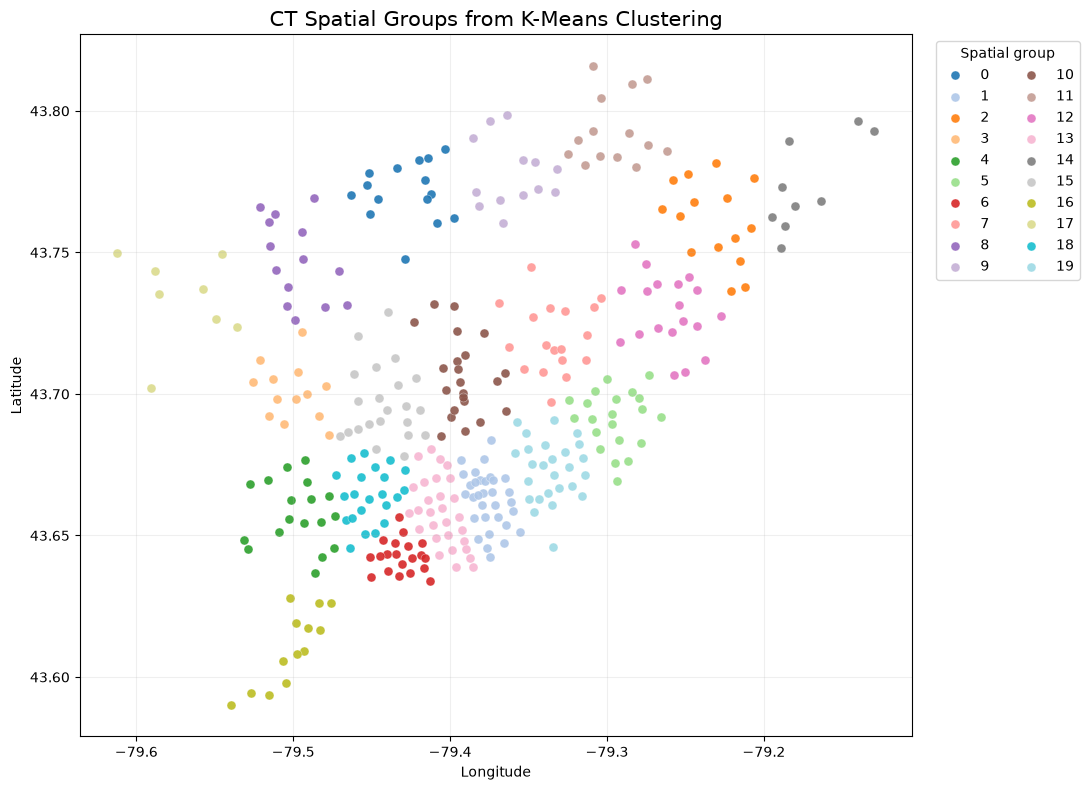

,fold_id,n_train_groups,n_val_groups,n_test_groups,train_pct,val_pct,test_pct
0,0,14,3,3,0.698554,0.150854,0.150592
1,1,14,3,3,0.700820,0.150777,0.148403
2,2,14,3,3,0.697637,0.154875,0.147487
3,3,14,3,3,0.698554,0.150592,0.150854
4,4,14,3,3,0.701034,0.148862,0.150104
5,5,14,3,3,0.700396,0.150742,0.148862
6,6,14,3,3,0.702658,0.148403,0.148939
7,7,14,3,3,0.700284,0.150854,0.148862
8,8,14,3,3,0.697113,0.147960,0.154927
9,9,14,3,3,0.698404,0.142784,0.158812


Host CTs plotted: 363
Spatial groups: 20
Spatial folds: 10


In [1]:
# Plot the 20 CT spatial groups and summarise the 10 spatial folds.
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path("/home/najla/dev/najla-msc/bikeshare")
MODEL_DIR = ROOT / "data/processed/model_df/desc_semantics"
MODEL_PATH = MODEL_DIR / "desc_df_2targets_txtTokens_graphFeat.parquet"
FOLDS_PATH = MODEL_DIR / "desc_folds_of_2targets_txtTokens_graphFeat.parquet"

fold_assignments = pd.read_parquet(FOLDS_PATH)
model_rows = pd.read_parquet(
    MODEL_PATH, columns=["loc_id", "lon", "lat", "spatial_group"]
)
model_rows["spatial_group"] = model_rows["spatial_group"].astype(int)
fold_assignments["spatial_group"] = fold_assignments["spatial_group"].astype(int)

# Keep one centroid point for each station-hosting census tract.
ct_groups = (
    model_rows[["loc_id", "lon", "lat", "spatial_group"]]
    .drop_duplicates(subset="loc_id")
    .sort_values(["spatial_group", "loc_id"])
)
groups = sorted(ct_groups["spatial_group"].unique())
assert groups == list(range(20)), f"Expected groups 0-19, found {groups}"

colour_map = plt.get_cmap("tab20", 20)
fig, ax = plt.subplots(figsize=(11, 8))
for group in groups:
    group_cts = ct_groups.loc[ct_groups["spatial_group"] == group]
    ax.scatter(
        group_cts["lon"], group_cts["lat"],
        s=42, color=colour_map(group), label=str(group),
        alpha=0.9, edgecolors="white", linewidths=0.25,
    )

ax.set_title("CT Spatial Groups from K-Means Clustering", fontsize=15)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)
ax.legend(
    title="Spatial group", bbox_to_anchor=(1.02, 1),
    loc="upper left", ncol=2, frameon=True,
)
fig.tight_layout()
plt.show()

# Calculate split percentages from the actual station-date rows.
group_row_counts = model_rows.groupby("spatial_group").size()
total_rows = len(model_rows)
fold_summary_rows = []
for fold_id, fold in fold_assignments.groupby("fold_id", sort=True):
    split_groups = {
        split: set(fold.loc[fold["split"] == split, "spatial_group"])
        for split in ["train", "val", "test"]
    }
    split_rows = {
        split: int(group_row_counts.reindex(sorted(group_ids), fill_value=0).sum())
        for split, group_ids in split_groups.items()
    }
    fold_summary_rows.append({
        "fold_id": int(fold_id),
        "n_train_groups": len(split_groups["train"]),
        "n_val_groups": len(split_groups["val"]),
        "n_test_groups": len(split_groups["test"]),
        "train_pct": split_rows["train"] / total_rows,
        "val_pct": split_rows["val"] / total_rows,
        "test_pct": split_rows["test"] / total_rows,
    })

fold_summary = pd.DataFrame(fold_summary_rows)
display(fold_summary.style.format({
    "train_pct": "{:.6f}",
    "val_pct": "{:.6f}",
    "test_pct": "{:.6f}",
}))
print(f"Host CTs plotted: {len(ct_groups):,}")
print(f"Spatial groups: {len(groups)}")
print(f"Spatial folds: {fold_assignments['fold_id'].nunique()}")
